In [1]:
import requests
import os
import time
import gzip
import json
import zipfile
import io
import re
import pandas as pd
from pathlib import Path

In [ ]:
# Replaced credentials with placeholders for purposes of data privacy 
API_KEY = "key"
USERNAME = "user"
PASSWORD = "password"

headers = {
    "Content-Type": "application/json",
    "Api-Key": API_KEY,
    "User-Agent": "lseresearch v1.0"
}

payload = {
    "username": USERNAME,
    "password": PASSWORD
}

r = requests.post(login_url, json=payload, headers=headers)
print(r.status_code)
print(r.json())

200
{'user': {'allowed_translations': 1, 'allowed_downloads': 20, 'level': 'Sub leecher', 'user_id': 1343593, 'ext_installed': False, 'vip': False}, 'token': 'REDACTED_OPENSUBTITLES_TOKEN', 'status': 200, 'base_url': 'api.opensubtitles.com'}


In [5]:
TOKEN = r.json()['token']

# Test: search for subtitles for a single film
search_url = "https://api.opensubtitles.com/api/v1/subtitles"

search_headers = {
    "Api-Key": API_KEY,
    "Authorization": f"Bearer {TOKEN}",
    "User-Agent": "filmlse v1.0"
}

params = {
    "year": 2023,
    "languages": "en",
    "type": "movie",
    "order_by": "download_count",
    "order_direction": "desc",
    "limit": 5
}

resp = requests.get(search_url, headers=search_headers, params=params)
print(resp.status_code)
print(json.dumps(resp.json(), indent=2)[:3000])

200
{
  "total_pages": 200,
  "total_count": 10000,
  "per_page": 50,
  "page": 1,
  "data": [
    {
      "id": "7187446",
      "type": "subtitle",
      "attributes": {
        "subtitle_id": "7187446",
        "language": "en",
        "download_count": 925002,
        "new_download_count": 32895,
        "hearing_impaired": false,
        "hd": true,
        "fps": 23.976,
        "votes": 5,
        "ratings": 10.0,
        "from_trusted": true,
        "foreign_parts_only": false,
        "upload_date": "2023-05-22T19:32:53Z",
        "ai_translated": false,
        "nb_cd": 1,
        "slug": "9565571-720p-web-dl-ddp5-1-atmos-h264-cmrg",
        "machine_translated": false,
        "release": "1080p.WEB-DL.DDP5.1.Atmos.H264-WDYM",
        "comments": "Duration = 02:49:17\r\nJohn.Wick.Chapter.4.2023.720p.WEB-DL.DDP5.1.Atmos.H264-CM\r\nJohn.Wick.Chapter.4.2023.2160p.WEB-DL.DDP5.1.Atmos.DV.MP4.x265-DVSUX\r\nJohn.Wick.Chapter.4.2023.2160p.WEB-DL.DDP5.1.Atmos.DV.MKV.x265-DVSUX\r\nJo

In [ ]:


TOKEN = r.json()['token']

search_headers = {
    "Api-Key": API_KEY,
    "Authorization": f"Bearer {TOKEN}",
    "User-Agent": "filmlse v1.0"
}

download_url = "https://api.opensubtitles.com/api/v1/download"
search_url = "https://api.opensubtitles.com/api/v1/subtitles"

Path("./data/raw/subtitles").mkdir(parents=True, exist_ok=True)

metadata = []

for year in range(2024, 2023, -1):  # just 2024
    print(f"\nFetching {year}...")
    
    params = {
        "year": year,
        "languages": "en",
        "type": "movie",
        "order_by": "download_count",
        "order_direction": "desc",
        "limit": 25
    }
    
    resp = requests.get(search_url, headers=search_headers, params=params)
    if resp.status_code != 200:
        print(f"  Search failed: {resp.status_code}")
        continue
    
    results = resp.json().get("data", [])
    seen_imdb = set()
    downloaded = 0
    
    for item in results:
        if downloaded >= 25:
            break
            
        attrs = item["attributes"]
        feature = attrs.get("feature_details", {})
        imdb_id = feature.get("imdb_id")
        title = feature.get("title", "unknown")
        file_id = attrs["files"][0]["file_id"]
        
        # Skip duplicates (same film, different subtitle upload)
        if imdb_id in seen_imdb:
            continue
        seen_imdb.add(imdb_id)
        
        # Request download link
        dl_resp = requests.post(
            download_url,
            headers=search_headers,
            json={"file_id": file_id}
        )
        
        if dl_resp.status_code != 200:
            print(f"  Download request failed for {title}: {dl_resp.status_code}")
            continue
        
        dl_data = dl_resp.json()
        link = dl_data.get("link")
        remaining = dl_data.get("remaining")
        print(f"  [{downloaded+1}] {title} ({imdb_id}) — {remaining} downloads remaining")
        
        # Download the actual SRT file
        srt = requests.get(link)
        year_dir = Path(f"./data/raw/subtitles/{year}")
        year_dir.mkdir(exist_ok=True)
        
        srt_path = year_dir / f"{imdb_id}.srt"
        with open(srt_path, "wb") as f:
            f.write(srt.content)
        
        metadata.append({
            "imdb_id": imdb_id,
            "title": title,
            "year": year,
            "file_id": file_id,
            "download_count": attrs["download_count"],
            "srt_path": str(srt_path)
        })
        
        downloaded += 1
        time.sleep(0.3)  # respect 5 req/s rate limit
    
    print(f"  Done: {downloaded} films saved for {year}")
    time.sleep(1)  # brief pause between years

# Save metadata
df = pd.DataFrame(metadata)
df.to_csv("./data/raw/metadata.csv", index=False)
print(f"\nTotal collected: {len(df)} films")
print(df.head())


Fetching 2024...
  [1] Kraven the Hunter (8790086) — 19 downloads remaining
  [2] Dune: Part Two (15239678) — 18 downloads remaining
  [3] The Beekeeper (15314262) — 17 downloads remaining
  [4] A Quiet Place: Day One (13433802) — 16 downloads remaining
  [5] Deadpool &amp; Wolverine (6263850) — 15 downloads remaining
  [6] Gladiator II (9218128) — 14 downloads remaining
  [7] Venom: The Last Dance (16366836) — 13 downloads remaining
  [8] Mission: Impossible - The Final Reckoning (9603208) — 12 downloads remaining
  [9] Inside Out 2 (22022452) — 11 downloads remaining
  [10] Kung Fu Panda 4 (21692408) — 10 downloads remaining
  [11] Anora (28607951) — 9 downloads remaining
  [12] Despicable Me 4 (7510222) — 8 downloads remaining
  [13] Heretic (28015403) — 7 downloads remaining
  [14] Sonic the Hedgehog 3 (18259086) — 6 downloads remaining
  [15] Bad Boys: Ride or Die (4919268) — 5 downloads remaining
  [16] Den of Thieves 2: Pantera (8008948) — 4 downloads remaining
  [17] Conclave 

In [7]:
# peek at one SRT file
with open("./data/raw/subtitles/2024/8790086.srt", "r", encoding="utf-8") as f:
    content = f.read()

print(content[:3000])

1
00:01:37,001 --> 00:01:41,015
You have five minutes.
Make sure to pee off.

2
00:01:50,023 --> 00:01:54,014
Where is 0864? 0864?

3
00:01:59,023 --> 00:02:03,005
Did you think we would
drive without you?

4
00:02:05,001 --> 00:02:10,020
You wouldn't survive an hour out
here. The wolves would eat you alive.

5
00:02:27,003 --> 00:02:32,022
RUSSIAN PRISON COLONY

6
00:03:18,015 --> 00:03:23,019
- I hate cellmates.
- Then we already have something in common.

7
00:03:23,021 --> 00:03:29,011
- The previous one only lasted a month.
- I'll be out again in three days.

8
00:03:29,013 --> 00:03:32,002
Everyone is here for life.

9
00:03:32,004 --> 00:03:35,014
One more minute and you'll
have to try to kill me.

10
00:03:39,008 --> 00:03:40,017
Top.

11
00:03:43,010 --> 00:03:46,004
May I sit and eat with you?

12
00:03:46,006 --> 00:03:48,010
No.

13
00:03:56,002 --> 00:03:59,005
You are in private territory.

14
00:03:59,007 --> 00:04:01,015
Fuck me.

15
00:04:05,011 --> 00:04:09,008
Who th

In [8]:
TOKEN = r.json()['token']

search_headers = {
    "Api-Key": API_KEY,
    "Authorization": f"Bearer {TOKEN}",
    "User-Agent": "filmlse v1.0"
}

download_url = "https://api.opensubtitles.com/api/v1/download"
search_url = "https://api.opensubtitles.com/api/v1/subtitles"

Path("./data/raw/subtitles").mkdir(parents=True, exist_ok=True)

# Load existing metadata if it exists so we don't re-download
if Path("./data/raw/metadata.csv").exists():
    existing_df = pd.read_csv("./data/raw/metadata.csv")
    existing_ids = set(zip(existing_df["imdb_id"], existing_df["year"]))
    metadata = existing_df.to_dict("records")
    print(f"Loaded {len(existing_df)} existing records")
else:
    existing_ids = set()
    metadata = []

for year in range(2024, 2017, -1):
    print(f"\nFetching {year}...")

    params = {
        "year": year,
        "languages": "en",
        "type": "movie",
        "order_by": "download_count",
        "order_direction": "desc",
        "limit": 50
    }

    resp = requests.get(search_url, headers=search_headers, params=params)
    if resp.status_code != 200:
        print(f"  Search failed: {resp.status_code}")
        continue

    results = resp.json().get("data", [])
    seen_imdb = set()
    downloaded = 0

    for item in results:
        if downloaded >= 50:
            break

        attrs = item["attributes"]
        feature = attrs.get("feature_details", {})
        imdb_id = feature.get("imdb_id")
        title = feature.get("title", "unknown")
        file_id = attrs["files"][0]["file_id"]

        # Skip duplicates
        if imdb_id in seen_imdb:
            continue
        seen_imdb.add(imdb_id)

        # Skip already downloaded
        if (imdb_id, year) in existing_ids:
            print(f"  Skipping {title} — already downloaded")
            downloaded += 1
            continue

        # Request download link
        dl_resp = requests.post(
            download_url,
            headers=search_headers,
            json={"file_id": file_id}
        )

        if dl_resp.status_code != 200:
            print(f"  Download request failed for {title}: {dl_resp.status_code}")
            continue

        dl_data = dl_resp.json()
        link = dl_data.get("link")
        remaining = dl_data.get("remaining")
        print(f"  [{downloaded+1}] {title} ({imdb_id}) — {remaining} downloads remaining")

        # Download the actual SRT file
        srt = requests.get(link)
        year_dir = Path(f"./data/raw/subtitles/{year}")
        year_dir.mkdir(exist_ok=True)

        srt_path = year_dir / f"{imdb_id}.srt"
        with open(srt_path, "wb") as f:
            f.write(srt.content)

        metadata.append({
            "imdb_id": imdb_id,
            "title": title,
            "year": year,
            "file_id": file_id,
            "download_count": attrs["download_count"],
            "srt_path": str(srt_path)
        })

        existing_ids.add((imdb_id, year))
        downloaded += 1
        time.sleep(0.3)

    print(f"  Done: {downloaded} films for {year}")
    time.sleep(1)

# Save updated metadata
df = pd.DataFrame(metadata)
df.to_csv("./data/raw/metadata.csv", index=False)
print(f"\nTotal collected: {len(df)} films")
print(df.groupby("year").size())

Loaded 25 existing records

Fetching 2024...
  Skipping Kraven the Hunter — already downloaded
  Skipping Dune: Part Two — already downloaded
  Skipping The Beekeeper — already downloaded
  Skipping A Quiet Place: Day One — already downloaded
  Skipping Deadpool &amp; Wolverine — already downloaded
  Skipping Gladiator II — already downloaded
  Skipping Venom: The Last Dance — already downloaded
  Skipping Mission: Impossible - The Final Reckoning — already downloaded
  Skipping Inside Out 2 — already downloaded
  Skipping Kung Fu Panda 4 — already downloaded
  Skipping Anora — already downloaded
  Skipping Despicable Me 4 — already downloaded
  Skipping Heretic — already downloaded
  Skipping Sonic the Hedgehog 3 — already downloaded
  Skipping Bad Boys: Ride or Die — already downloaded
  Skipping Den of Thieves 2: Pantera — already downloaded
  Skipping Conclave — already downloaded
  Skipping Godzilla x Kong: The New Empire — already downloaded
  Skipping Red One — already downloade

In [ ]:
TOKEN = r.json()['token']

search_headers = {
    "Api-Key": API_KEY,
    "Authorization": f"Bearer {TOKEN}",
    "User-Agent": "filmlse v1.0"
}

download_url = "https://api.opensubtitles.com/api/v1/download"
search_url = "https://api.opensubtitles.com/api/v1/subtitles"

Path("./data/raw/subtitles").mkdir(parents=True, exist_ok=True)

# Load existing metadata
if Path("./data/raw/metadata.csv").exists():
    existing_df = pd.read_csv("./data/raw/metadata.csv")
    existing_ids = set(zip(existing_df["imdb_id"], existing_df["year"]))
    metadata = existing_df.to_dict("records")
    print(f"Loaded {len(existing_df)} existing records")
else:
    existing_ids = set()
    metadata = []

for year in range(2025, 1999, -1):
    print(f"\nFetching {year}...")

    params = {
        "year": year,
        "languages": "en",
        "type": "movie",
        "order_by": "download_count",
        "order_direction": "desc",
        "limit": 50
    }

    resp = requests.get(search_url, headers=search_headers, params=params)
    if resp.status_code != 200:
        print(f"  Search failed: {resp.status_code}")
        continue

    results = resp.json().get("data", [])
    seen_imdb = set()
    downloaded = 0

    for item in results:
        if downloaded >= 50:
            break

        attrs = item["attributes"]
        feature = attrs.get("feature_details", {})
        imdb_id = feature.get("imdb_id")
        title = feature.get("title", "unknown")
        file_id = attrs["files"][0]["file_id"]

        if imdb_id in seen_imdb:
            continue
        seen_imdb.add(imdb_id)

        # Skip already downloaded
        if (imdb_id, year) in existing_ids:
            print(f"  Skipping {title} — already downloaded")
            downloaded += 1
            continue

        # Request download link
        dl_resp = requests.post(
            download_url,
            headers=search_headers,
            json={"file_id": file_id}
        )

        if dl_resp.status_code != 200:
            print(f"  Download request failed for {title}: {dl_resp.status_code}")
            continue

        dl_data = dl_resp.json()
        link = dl_data.get("link")
        remaining = dl_data.get("remaining")
        print(f"  [{downloaded+1}] {title} ({imdb_id}) — {remaining} downloads remaining")

        # Download the actual SRT file
        srt = requests.get(link)
        year_dir = Path(f"./data/raw/subtitles/{year}")
        year_dir.mkdir(exist_ok=True)

        srt_path = year_dir / f"{imdb_id}.srt"
        with open(srt_path, "wb") as f:
            f.write(srt.content)

        metadata.append({
            "imdb_id": imdb_id,
            "title": title,
            "year": year,
            "file_id": file_id,
            "download_count": attrs["download_count"],
            "srt_path": str(srt_path)
        })

        existing_ids.add((imdb_id, year))
        downloaded += 1
        time.sleep(0.3)

    print(f"  Done: {downloaded} films for {year}")
    time.sleep(1)

# Save updated metadata
df = pd.DataFrame(metadata)
df.to_csv("./data/raw/metadata.csv", index=False)
print(f"\nTotal collected: {len(df)} films")
print(df.groupby("year").size())

In [ ]:
# Let's see whether we actually managed to get substantial data 
df = pd.read_csv("./data/raw/metadata.csv")
print(f"Total collected: {len(df)} films")
print(df.groupby("year").size())

Total collected: 290 films
year
2018    39
2019    36
2020    42
2021    41
2022    44
2023    45
2024    43
dtype: int64


In [11]:
df = pd.read_csv("./data/raw/metadata.csv")
print(f"Total collected: {len(df)} films")
print(df.groupby("year").size())

Total collected: 290 films
year
2018    39
2019    36
2020    42
2021    41
2022    44
2023    45
2024    43
dtype: int64


In [12]:
# Count actual SRT files on disk
import os

total = 0
for year_dir in sorted(Path("./data/raw/subtitles").iterdir()):
    count = len(list(year_dir.glob("*.srt")))
    print(f"{year_dir.name}: {count} files")
    total += count

print(f"\nTotal SRT files on disk: {total}")

2003: 15 files
2004: 32 files
2005: 28 files
2006: 24 files
2007: 33 files
2008: 33 files
2009: 32 files
2010: 29 files
2011: 30 files
2012: 31 files
2013: 35 files
2014: 34 files
2015: 34 files
2016: 32 files
2017: 32 files
2018: 39 files
2019: 36 files
2020: 42 files
2021: 41 files
2022: 44 files
2023: 45 files
2024: 43 files
2025: 43 files

Total SRT files on disk: 787


In [13]:
# Rebuild metadata from disk by querying API for each imdb_id we have
metadata = []

for year_dir in sorted(Path("./data/raw/subtitles").iterdir()):
    year = int(year_dir.name)
    for srt_file in year_dir.glob("*.srt"):
        imdb_id = int(srt_file.stem)
        metadata.append({
            "imdb_id": imdb_id,
            "year": year,
            "srt_path": str(srt_file)
        })

df_disk = pd.DataFrame(metadata)
print(f"Total files on disk: {len(df_disk)}")
print(df_disk.groupby("year").size())

# Merge with existing metadata to recover titles and download counts
existing_df = pd.read_csv("./data/raw/metadata.csv")
merged = df_disk.merge(existing_df[["imdb_id", "title", "download_count", "file_id"]], 
                        on="imdb_id", how="left")

print(f"\nRecovered titles: {merged['title'].notna().sum()}")
print(f"Missing titles: {merged['title'].isna().sum()}")

# Save rebuilt metadata
merged.to_csv("./data/raw/metadata.csv", index=False)
print("\nMetadata rebuilt and saved.")

Total files on disk: 787
year
2003    15
2004    32
2005    28
2006    24
2007    33
2008    33
2009    32
2010    29
2011    30
2012    31
2013    35
2014    34
2015    34
2016    32
2017    32
2018    39
2019    36
2020    42
2021    41
2022    44
2023    45
2024    43
2025    43
dtype: int64

Recovered titles: 290
Missing titles: 497

Metadata rebuilt and saved.


In [16]:
TMDB_API_KEY = "YOUR_TMDB_API_KEY"
TMDB_BASE = "https://api.themoviedb.org/3"

# Test with a known IMDb ID (Inception)
test_url = f"{TMDB_BASE}/find/tt1375666"
params = {
    "api_key": TMDB_API_KEY,
    "external_source": "imdb_id"
}

r = requests.get(test_url, params=params)
print(r.status_code)
print(r.json())

200
{'movie_results': [{'adult': False, 'backdrop_path': '/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg', 'id': 27205, 'title': 'Inception', 'original_title': 'Inception', 'overview': 'Cobb, a skilled thief who commits corporate espionage by infiltrating the subconscious of his targets is offered a chance to regain his old life as payment for a task considered to be impossible: "inception", the implantation of another person\'s idea into a target\'s subconscious.', 'poster_path': '/xlaY2zyzMfkhk0HSC5VUwzoZPU1.jpg', 'media_type': 'movie', 'original_language': 'en', 'genre_ids': [28, 878, 12], 'popularity': 37.7947, 'release_date': '2010-07-15', 'video': False, 'vote_average': 8.372, 'vote_count': 39044}], 'person_results': [], 'tv_results': [], 'tv_episode_results': [], 'tv_season_results': []}


In [17]:
TMDB_API_KEY = "YOUR_TMDB_API_KEY"
TMDB_BASE = "https://api.themoviedb.org/3"

# Genre ID to name mapping
genre_map = {
    28: "Action", 12: "Adventure", 16: "Animation", 35: "Comedy",
    80: "Crime", 99: "Documentary", 18: "Drama", 10751: "Family",
    14: "Fantasy", 36: "History", 27: "Horror", 10402: "Music",
    9648: "Mystery", 10749: "Romance", 878: "Science Fiction",
    10770: "TV Movie", 53: "Thriller", 10752: "War", 37: "Western"
}

df = pd.read_csv("./data/raw/metadata.csv")
print(f"Enriching {len(df)} films...")

enriched = []

for i, row in df.iterrows():
    imdb_id = row["imdb_id"]
    imdb_str = f"tt{int(imdb_id):07d}"
    
    try:
        # Step 1: Find TMDb ID from IMDb ID
        find_url = f"{TMDB_BASE}/find/{imdb_str}"
        r = requests.get(find_url, params={
            "api_key": TMDB_API_KEY,
            "external_source": "imdb_id"
        })
        
        results = r.json().get("movie_results", [])
        if not results:
            print(f"  [{i}] Not found: {imdb_str}")
            enriched.append({**row, "tmdb_id": None, "genres": None, "runtime": None,
                            "budget": None, "franchise": None, "original_language": None})
            continue
        
        tmdb_id = results[0]["id"]
        original_language = results[0]["original_language"]
        
        # Step 2: Get full movie details
        detail_url = f"{TMDB_BASE}/movie/{tmdb_id}"
        r2 = requests.get(detail_url, params={"api_key": TMDB_API_KEY})
        details = r2.json()
        
        genres = [genre_map.get(g["id"], g["name"]) for g in details.get("genres", [])]
        runtime = details.get("runtime")
        budget = details.get("budget")
        franchise = 1 if details.get("belongs_to_collection") else 0
        
        if i % 50 == 0:
            print(f"  [{i}/{len(df)}] {details.get('title')} — genres: {genres}")
        
        enriched.append({
            **row,
            "tmdb_id": tmdb_id,
            "genres": "|".join(genres),
            "runtime": runtime,
            "budget": budget,
            "franchise": franchise,
            "original_language": original_language
        })
        
        time.sleep(0.25)  # TMDb rate limit is 40 req/s, being conservative
        
    except Exception as e:
        print(f"  [{i}] Error for {imdb_str}: {e}")
        enriched.append({**row, "tmdb_id": None, "genres": None, "runtime": None,
                        "budget": None, "franchise": None, "original_language": None})

# Save enriched metadata
df_enriched = pd.DataFrame(enriched)
df_enriched.to_csv("./data/raw/metadata.csv", index=False)
print(f"\nDone. Enriched {df_enriched['tmdb_id'].notna().sum()} of {len(df_enriched)} films")
print(df_enriched[["title", "year", "genres", "runtime", "budget", "franchise"]].head(10))

Enriching 787 films...
  [0/787] The Lord of the Rings: The Return of the King — genres: ['Adventure', 'Fantasy', 'Action']
  [50/787] Kingdom of Heaven — genres: ['Drama', 'Action', 'Adventure', 'History', 'War']
  [100/787] Rush Hour 3 — genres: ['Action', 'Comedy', 'Crime']
  [150/787] Wanted — genres: ['Action', 'Thriller', 'Crime']
  [200/787] Undisputed III: Redemption — genres: ['Action', 'Thriller', 'Crime', 'Drama']
  [250/787] Real Steel — genres: ['Action', 'Science Fiction', 'Drama']
  [300/787] Despicable Me 2 — genres: ['Animation', 'Comedy', 'Family']
  [350/787] Brotherhood of Blades — genres: ['Romance', 'Action', 'Drama']
  [400/787] The Huntsman: Winter's War — genres: ['Action', 'Adventure', 'Drama']
  [450/787] After Porn Ends 2 — genres: ['Documentary']
  [500/787] Men in Black: International — genres: ['Comedy', 'Science Fiction', 'Action', 'Adventure']
  [550/787] Onward — genres: ['Animation', 'Family', 'Fantasy', 'Adventure', 'Comedy']
  [600/787] The Boss Bab

In [18]:
# Fix missing titles from TMDb data
df = pd.read_csv("./data/raw/metadata.csv")
print(f"Missing titles: {df['title'].isna().sum()}")

# Re-enrich just the missing titles
for i, row in df[df['title'].isna()].iterrows():
    imdb_str = f"tt{int(row['imdb_id']):07d}"
    try:
        r = requests.get(f"{TMDB_BASE}/find/{imdb_str}", params={
            "api_key": TMDB_API_KEY,
            "external_source": "imdb_id"
        })
        results = r.json().get("movie_results", [])
        if results:
            df.at[i, "title"] = results[0]["title"]
        time.sleep(0.25)
    except Exception as e:
        print(f"Error for {imdb_str}: {e}")

df.to_csv("./data/raw/metadata.csv", index=False)
print(f"Missing titles after fix: {df['title'].isna().sum()}")
print(df[["title", "year", "genres", "runtime", "budget", "franchise"]].head(10))

Missing titles: 497
Missing titles after fix: 0
                                           title  year  \
0  The Lord of the Rings: The Return of the King  2003   
1                                    Bad Boys II  2003   
2                            The Matrix Reloaded  2003   
3                         The Matrix Revolutions  2003   
4                   How to Lose a Guy in 10 Days  2003   
5                                   Finding Nemo  2003   
6                              Kill Bill: Vol. 1  2003   
7                                 Johnny English  2003   
8                                             X2  2003   
9                                  Love Actually  2003   

                                      genres  runtime     budget  franchise  
0                   Adventure|Fantasy|Action      201   94000000          1  
1                        Action|Crime|Comedy      146  130000000          1  
2  Adventure|Action|Thriller|Science Fiction      138  150000000          1  
3

In [19]:
df = pd.read_csv("./data/raw/metadata.csv")


print(f"Total films: {len(df)}")
print(f"\nFilms per year:")
print(df.groupby("year").size().to_string())
print(f"\nGenre distribution (top 10):")
genre_counts = df["genres"].str.split("|").explode().value_counts()
print(genre_counts.head(10))
print(f"\nFranchise vs original:")
print(df["franchise"].value_counts())
print(f"\nBudget stats:")
print(df[df["budget"] > 0]["budget"].describe())
print(f"\nRuntime stats:")
print(df[df["runtime"] > 0]["runtime"].describe())

Total films: 787

Films per year:
year
2003    15
2004    32
2005    28
2006    24
2007    33
2008    33
2009    32
2010    29
2011    30
2012    31
2013    35
2014    34
2015    34
2016    32
2017    32
2018    39
2019    36
2020    42
2021    41
2022    44
2023    45
2024    43
2025    43

Genre distribution (top 10):
genres
Action             393
Adventure          288
Thriller           234
Drama              220
Science Fiction    195
Comedy             194
Fantasy            135
Crime              115
Family             104
Romance             95
Name: count, dtype: int64

Franchise vs original:
franchise
1    431
0    356
Name: count, dtype: int64

Budget stats:
count    7.380000e+02
mean     9.587576e+07
std      7.621581e+07
min      7.000000e+03
25%      3.200000e+07
50%      8.000000e+07
75%      1.500000e+08
max      4.650000e+08
Name: budget, dtype: float64

Runtime stats:
count    787.000000
mean     119.155019
std       21.831913
min        6.000000
25%      103.000000
5

In [20]:
import re
import html

def parse_srt(filepath):
    """
    Takes a raw SRT file and returns:
    - clean_text: single string of all dialogue
    - lines: list of individual dialogue lines
    """
    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        content = f.read()
    
    # Decode HTML entities (&amp; → &, &quot; → ", etc.)
    content = html.unescape(content)
    
    # Remove timestamp lines (00:01:37,001 --> 00:01:41,015)
    content = re.sub(r"\d{2}:\d{2}:\d{2},\d{3} --> \d{2}:\d{2}:\d{2},\d{3}", "", content)
    
    # Remove subtitle index numbers (lone integers on a line)
    content = re.sub(r"^\d+\s*$", "", content, flags=re.MULTILINE)
    
    # Remove HTML tags (<i>, <b>, <font color=...>, etc.)
    content = re.sub(r"<[^>]+>", "", content)
    
    # Remove sound descriptions ([MUSIC], (APPLAUSE), [GUNSHOT], etc.)
    content = re.sub(r"[\[\(][^\]\)]*[\]\)]", "", content)
    
    # Remove speaker labels (JOHN:, DR. SMITH:, etc.)
    content = re.sub(r"^[A-Z][A-Z\s\.]+:\s*", "", content, flags=re.MULTILINE)
    
    # Remove music symbols and other non-dialogue characters
    content = re.sub(r"♪[^♪]*♪", "", content)
    content = re.sub(r"♪", "", content)
    
    # Clean up whitespace
    lines = [line.strip() for line in content.splitlines()]
    lines = [line for line in lines if len(line) > 2]  # remove very short fragments
    
    clean_text = " ".join(lines)
    clean_text = re.sub(r"\s+", " ", clean_text).strip()
    
    return clean_text, lines


# Test on one file first
test_path = "./data/raw/subtitles/2024/8790086.srt"
clean_text, lines = parse_srt(test_path)

print(f"Total lines: {len(lines)}")
print(f"Total characters: {len(clean_text)}")
print(f"\nFirst 10 lines:")
for line in lines[:10]:
    print(f"  {line}")
print(f"\nClean text sample:")
print(clean_text[:500])

Total lines: 1293
Total characters: 30827

First 10 lines:
  You have five minutes.
  Make sure to pee off.
  Where is 0864? 0864?
  Did you think we would
  drive without you?
  You wouldn't survive an hour out
  here. The wolves would eat you alive.
  RUSSIAN PRISON COLONY
  - I hate cellmates.
  - Then we already have something in common.

Clean text sample:
You have five minutes. Make sure to pee off. Where is 0864? 0864? Did you think we would drive without you? You wouldn't survive an hour out here. The wolves would eat you alive. RUSSIAN PRISON COLONY - I hate cellmates. - Then we already have something in common. - The previous one only lasted a month. - I'll be out again in three days. Everyone is here for life. One more minute and you'll have to try to kill me. Top. May I sit and eat with you? No. You are in private territory. Fuck me. Who th


In [21]:
def parse_srt(filepath):
    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        content = f.read()
    
    content = html.unescape(content)
    content = re.sub(r"\d{2}:\d{2}:\d{2},\d{3} --> \d{2}:\d{2}:\d{2},\d{3}", "", content)
    content = re.sub(r"^\d+\s*$", "", content, flags=re.MULTILINE)
    content = re.sub(r"<[^>]+>", "", content)
    content = re.sub(r"[\[\(][^\]\)]*[\]\)]", "", content)
    content = re.sub(r"^[A-Z][A-Z\s\.]+:\s*", "", content, flags=re.MULTILINE)
    content = re.sub(r"♪[^♪]*♪", "", content)
    content = re.sub(r"♪", "", content)
    
    # Remove leading dashes from dual-speaker lines
    content = re.sub(r"^\s*-\s*", "", content, flags=re.MULTILINE)
    
    lines = [line.strip() for line in content.splitlines()]
    
    # Remove all-caps lines (scene descriptions, location cards)
    lines = [line for line in lines if not re.match(r"^[A-Z\s\d,\.!']+$", line)]
    
    # Remove very short fragments
    lines = [line for line in lines if len(line) > 2]
    
    clean_text = " ".join(lines)
    clean_text = re.sub(r"\s+", " ", clean_text).strip()
    
    return clean_text, lines

# Test again
clean_text, lines = parse_srt(test_path)
print(f"Total lines: {len(lines)}")
print(f"Total characters: {len(clean_text)}")
print(f"\nFirst 10 lines:")
for line in lines[:10]:
    print(f"  {line}")
print(f"\nClean text sample:")
print(clean_text[:500])

Total lines: 1275
Total characters: 30199

First 10 lines:
  You have five minutes.
  Make sure to pee off.
  Where is 0864? 0864?
  Did you think we would
  drive without you?
  You wouldn't survive an hour out
  here. The wolves would eat you alive.
  I hate cellmates.
  Then we already have something in common.
  The previous one only lasted a month.

Clean text sample:
You have five minutes. Make sure to pee off. Where is 0864? 0864? Did you think we would drive without you? You wouldn't survive an hour out here. The wolves would eat you alive. I hate cellmates. Then we already have something in common. The previous one only lasted a month. I'll be out again in three days. Everyone is here for life. One more minute and you'll have to try to kill me. Top. May I sit and eat with you? No. You are in private territory. Fuck me. Who the hell do you think you are, f


In [22]:
from pathlib import Path
import pandas as pd

df = pd.read_csv("./data/raw/metadata.csv")

# Check if processed file already exists (for idempotency)
processed_path = Path("./data/processed/clean_texts.csv")
processed_path.parent.mkdir(exist_ok=True)

if processed_path.exists():
    processed_df = pd.read_csv(processed_path)
    already_done = set(processed_df["imdb_id"].tolist())
    print(f"Already processed: {len(already_done)} films")
else:
    processed_df = pd.DataFrame()
    already_done = set()

results = []
failed = []

for i, row in df.iterrows():
    imdb_id = row["imdb_id"]
    
    if imdb_id in already_done:
        continue
    
    srt_path = row["srt_path"]
    
    if not Path(srt_path).exists():
        print(f"  Missing file: {srt_path}")
        failed.append(imdb_id)
        continue
    
    try:
        clean_text, lines = parse_srt(srt_path)
        
        results.append({
            "imdb_id": imdb_id,
            "title": row["title"],
            "year": row["year"],
            "genres": row["genres"],
            "runtime": row["runtime"],
            "budget": row["budget"],
            "franchise": row["franchise"],
            "clean_text": clean_text,
            "num_lines": len(lines),
            "num_chars": len(clean_text),
            "num_words": len(clean_text.split())
        })
        
        if i % 100 == 0:
            print(f"  [{i}/{len(df)}] {row['title']} — {len(lines)} lines")
            
    except Exception as e:
        print(f"  Failed: {row['title']} — {e}")
        failed.append(imdb_id)

# Combine with any previously processed
new_df = pd.DataFrame(results)
if not processed_df.empty:
    final_df = pd.concat([processed_df, new_df], ignore_index=True)
else:
    final_df = new_df

final_df.to_csv(processed_path, index=False)
print(f"\nDone. Processed {len(final_df)} films")
print(f"Failed: {len(failed)}")
print(f"\nSample stats:")
print(final_df[["year", "num_lines", "num_words"]].groupby("year").mean().round(0))

  [0/787] The Lord of the Rings: The Return of the King — 2294 lines
  [100/787] Rush Hour 3 — 2088 lines
  [200/787] Undisputed III: Redemption — 1014 lines
  [300/787] Despicable Me 2 — 1500 lines
  [400/787] The Huntsman: Winter's War — 1372 lines
  [500/787] Men in Black: International — 2502 lines
  [600/787] The Boss Baby: Family Business — 3450 lines
  [700/787] Aquaman and the Lost Kingdom — 1710 lines

Done. Processed 787 films
Failed: 0

Sample stats:
      num_lines  num_words
year                      
2003     1958.0     8479.0
2004     1600.0     7077.0
2005     1864.0     8319.0
2006     1858.0     8360.0
2007     2014.0     9050.0
2008     1661.0     7574.0
2009     1766.0     7852.0
2010     1420.0     6503.0
2011     1793.0     8213.0
2012     1781.0     7942.0
2013     1958.0     8190.0
2014     1892.0     7953.0
2015     1835.0     8017.0
2016     1676.0     7343.0
2017     1739.0     7306.0
2018     1775.0     7074.0
2019     1983.0     7710.0
2020     1837.0     7

NaN clean_texts: 4


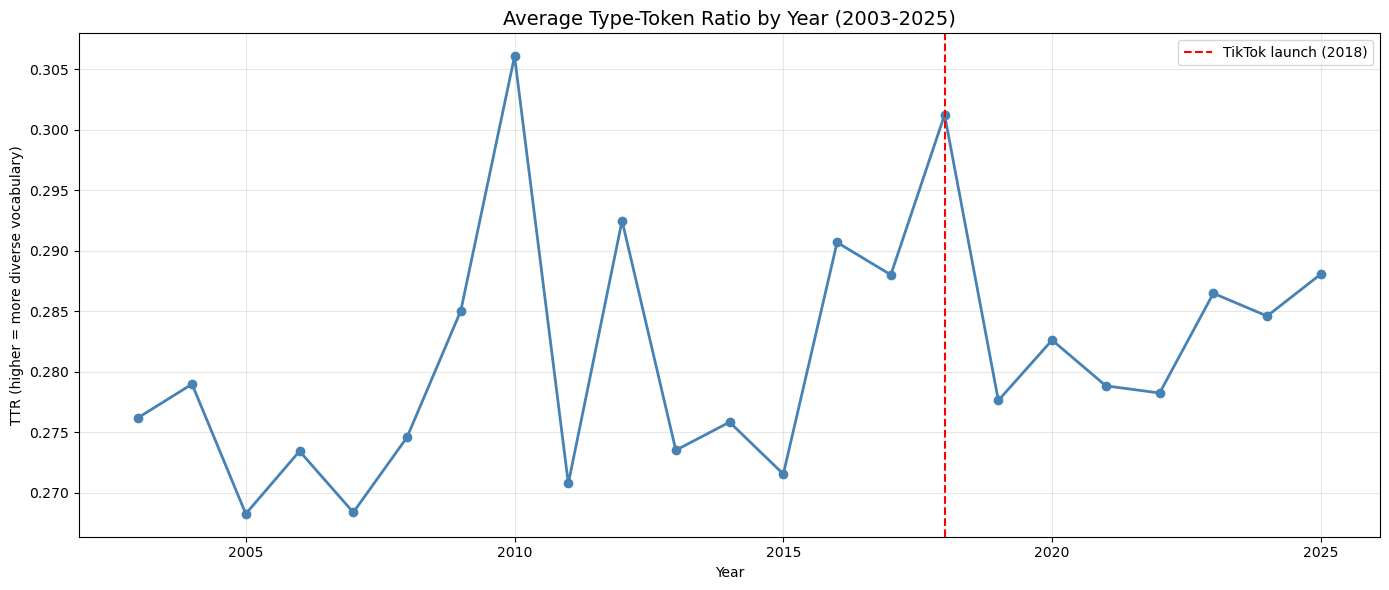


TTR by year:
year
2003    0.2762
2004    0.2790
2005    0.2682
2006    0.2734
2007    0.2684
2008    0.2746
2009    0.2850
2010    0.3061
2011    0.2708
2012    0.2925
2013    0.2735
2014    0.2758
2015    0.2715
2016    0.2907
2017    0.2880
2018    0.3012
2019    0.2776
2020    0.2826
2021    0.2788
2022    0.2782
2023    0.2865
2024    0.2846
2025    0.2881


In [24]:
def compute_ttr(text):
    if not isinstance(text, str) or len(text) == 0:
        return np.nan
    words = text.lower().split()
    if len(words) == 0:
        return np.nan
    return len(set(words)) / len(words)

# Check how many NaN clean_texts we have
print(f"NaN clean_texts: {df_processed['clean_text'].isna().sum()}")

df_processed["ttr"] = df_processed["clean_text"].apply(compute_ttr)

# Plot TTR over time
ttr_by_year = df_processed.groupby("year")["ttr"].mean()

plt.figure(figsize=(14, 6))
plt.plot(ttr_by_year.index, ttr_by_year.values, marker="o", linewidth=2, color="steelblue")
plt.axvline(x=2018, color="red", linestyle="--", linewidth=1.5, label="TikTok launch (2018)")
plt.title("Average Type-Token Ratio by Year (2003-2025)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("TTR (higher = more diverse vocabulary)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("./data/processed/ttr_over_time.png", dpi=150)
plt.show()

print("\nTTR by year:")
print(ttr_by_year.round(4).to_string())

In [26]:
nan_films = df_processed[df_processed["clean_text"].isna()]
print(nan_films[["title", "year"]])

                 title  year
19   Finding Neverland  2004
42        White Chicks  2004
53    Mr. & Mrs. Smith  2005
229          Limitless  2011


In [27]:
# Get their IMDb IDs and check the raw SRT files
nan_ids = nan_films["imdb_id"].tolist()
df_meta = pd.read_csv("./data/raw/metadata.csv")
nan_meta = df_meta[df_meta["imdb_id"].isin(nan_ids)]
print(nan_meta[["title", "year", "imdb_id", "srt_path"]])

                 title  year  imdb_id                             srt_path
19   Finding Neverland  2004   308644   data\raw\subtitles\2004\308644.srt
42        White Chicks  2004   381707   data\raw\subtitles\2004\381707.srt
53    Mr. & Mrs. Smith  2005   356910   data\raw\subtitles\2005\356910.srt
229          Limitless  2011  1219289  data\raw\subtitles\2011\1219289.srt


In [28]:
for _, row in nan_meta.iterrows():
    print(f"\n=== {row['title']} ===")
    try:
        with open(row['srt_path'], "rb") as f:
            raw = f.read(500)
        print(f"Raw bytes preview: {raw[:200]}")
        print(f"File size: {len(raw)} bytes")
    except Exception as e:
        print(f"Error: {e}")


=== Finding Neverland ===
Raw bytes preview: b''
File size: 0 bytes

=== White Chicks ===
Raw bytes preview: b''
File size: 0 bytes

=== Mr. & Mrs. Smith ===
Raw bytes preview: b''
File size: 0 bytes

=== Limitless ===
Raw bytes preview: b''
File size: 0 bytes


In [29]:
# Remove the 4 empty files from processed dataframe
df_processed = df_processed[df_processed["clean_text"].notna()].reset_index(drop=True)

# Also remove from metadata
df_meta = pd.read_csv("./data/raw/metadata.csv")
df_meta = df_meta[~df_meta["imdb_id"].isin(nan_ids)].reset_index(drop=True)

# Save both
df_processed.to_csv("./data/processed/clean_texts.csv", index=False)
df_meta.to_csv("./data/raw/metadata.csv", index=False)

print(f"Remaining films: {len(df_processed)}")

Remaining films: 783


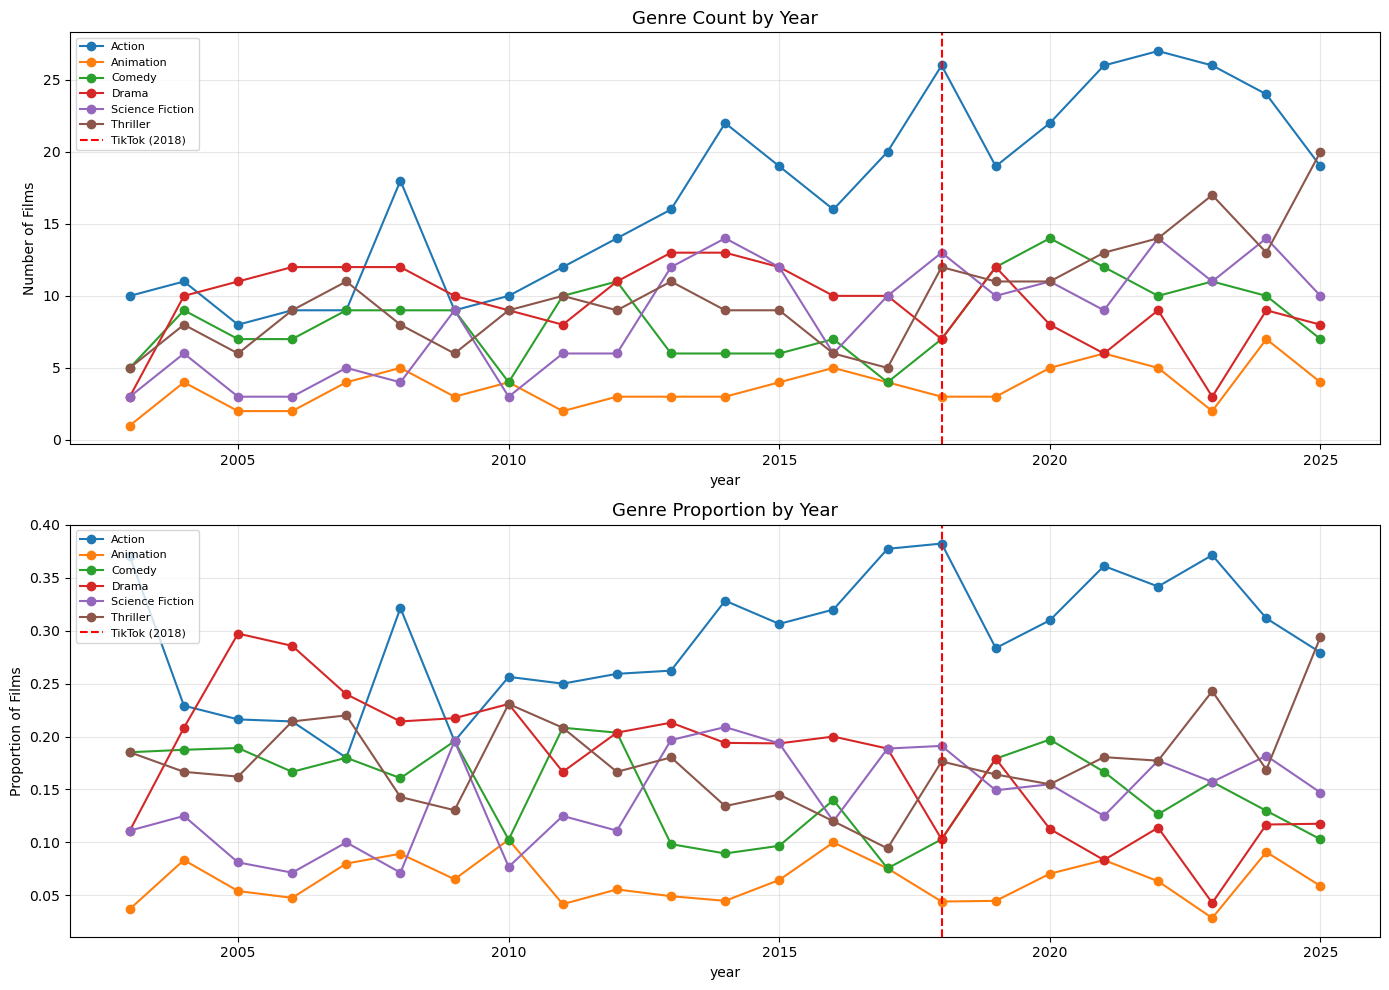

In [30]:
# Genre composition over time
genre_year = df_processed.copy()
genre_year["genres_list"] = genre_year["genres"].str.split("|")
genre_exploded = genre_year.explode("genres_list")

# Focus on top 6 genres
top_genres = ["Action", "Drama", "Comedy", "Thriller", "Animation", "Science Fiction"]

genre_pivot = genre_exploded[genre_exploded["genres_list"].isin(top_genres)]\
    .groupby(["year", "genres_list"])\
    .size()\
    .unstack(fill_value=0)

# Normalise to proportion per year
genre_pivot_pct = genre_pivot.div(genre_pivot.sum(axis=1), axis=0)

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Raw counts
genre_pivot.plot(ax=axes[0], marker="o", linewidth=1.5)
axes[0].axvline(x=2018, color="red", linestyle="--", linewidth=1.5, label="TikTok (2018)")
axes[0].set_title("Genre Count by Year", fontsize=13)
axes[0].set_ylabel("Number of Films")
axes[0].legend(loc="upper left", fontsize=8)
axes[0].grid(alpha=0.3)

# Plot 2: Proportions
genre_pivot_pct.plot(ax=axes[1], marker="o", linewidth=1.5)
axes[1].axvline(x=2018, color="red", linestyle="--", linewidth=1.5, label="TikTok (2018)")
axes[1].set_title("Genre Proportion by Year", fontsize=13)
axes[1].set_ylabel("Proportion of Films")
axes[1].legend(loc="upper left", fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("./data/processed/genre_over_time.png", dpi=150)
plt.show()

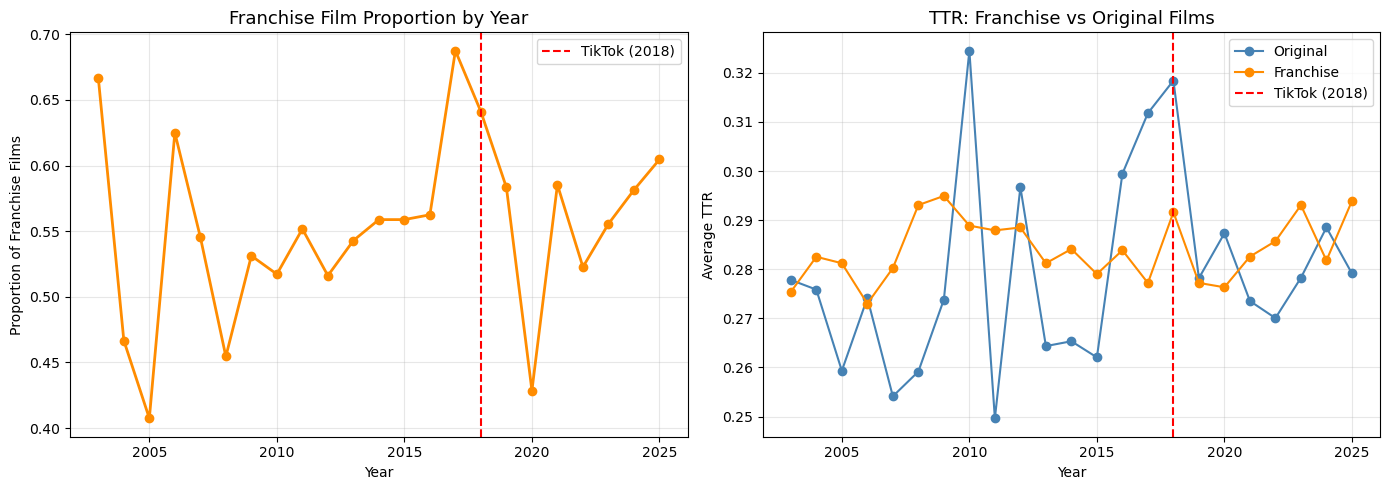


Franchise proportion by year:
year
2003    0.667
2004    0.467
2005    0.407
2006    0.625
2007    0.545
2008    0.455
2009    0.531
2010    0.517
2011    0.552
2012    0.516
2013    0.543
2014    0.559
2015    0.559
2016    0.562
2017    0.688
2018    0.641
2019    0.583
2020    0.429
2021    0.585
2022    0.523
2023    0.556
2024    0.581
2025    0.605


In [31]:
# Franchise proportion over time
franchise_by_year = df_processed.groupby("year")["franchise"].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Franchise proportion over time
axes[0].plot(franchise_by_year.index, franchise_by_year.values, 
             marker="o", linewidth=2, color="darkorange")
axes[0].axvline(x=2018, color="red", linestyle="--", linewidth=1.5, label="TikTok (2018)")
axes[0].set_title("Franchise Film Proportion by Year", fontsize=13)
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Proportion of Franchise Films")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Franchise vs original TTR comparison
ttr_franchise = df_processed.groupby(["year", "franchise"])["ttr"].mean().unstack()
ttr_franchise.columns = ["Original", "Franchise"]
ttr_franchise.plot(ax=axes[1], marker="o", linewidth=1.5, 
                   color=["steelblue", "darkorange"])
axes[1].axvline(x=2018, color="red", linestyle="--", linewidth=1.5, label="TikTok (2018)")
axes[1].set_title("TTR: Franchise vs Original Films", fontsize=13)
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Average TTR")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("./data/processed/franchise_over_time.png", dpi=150)
plt.show()

print("\nFranchise proportion by year:")
print(franchise_by_year.round(3).to_string())

C:\Users\dhruv\AppData\Local\Temp\ipykernel_22112\2336771005.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for era, group in df_processed.groupby("era"):


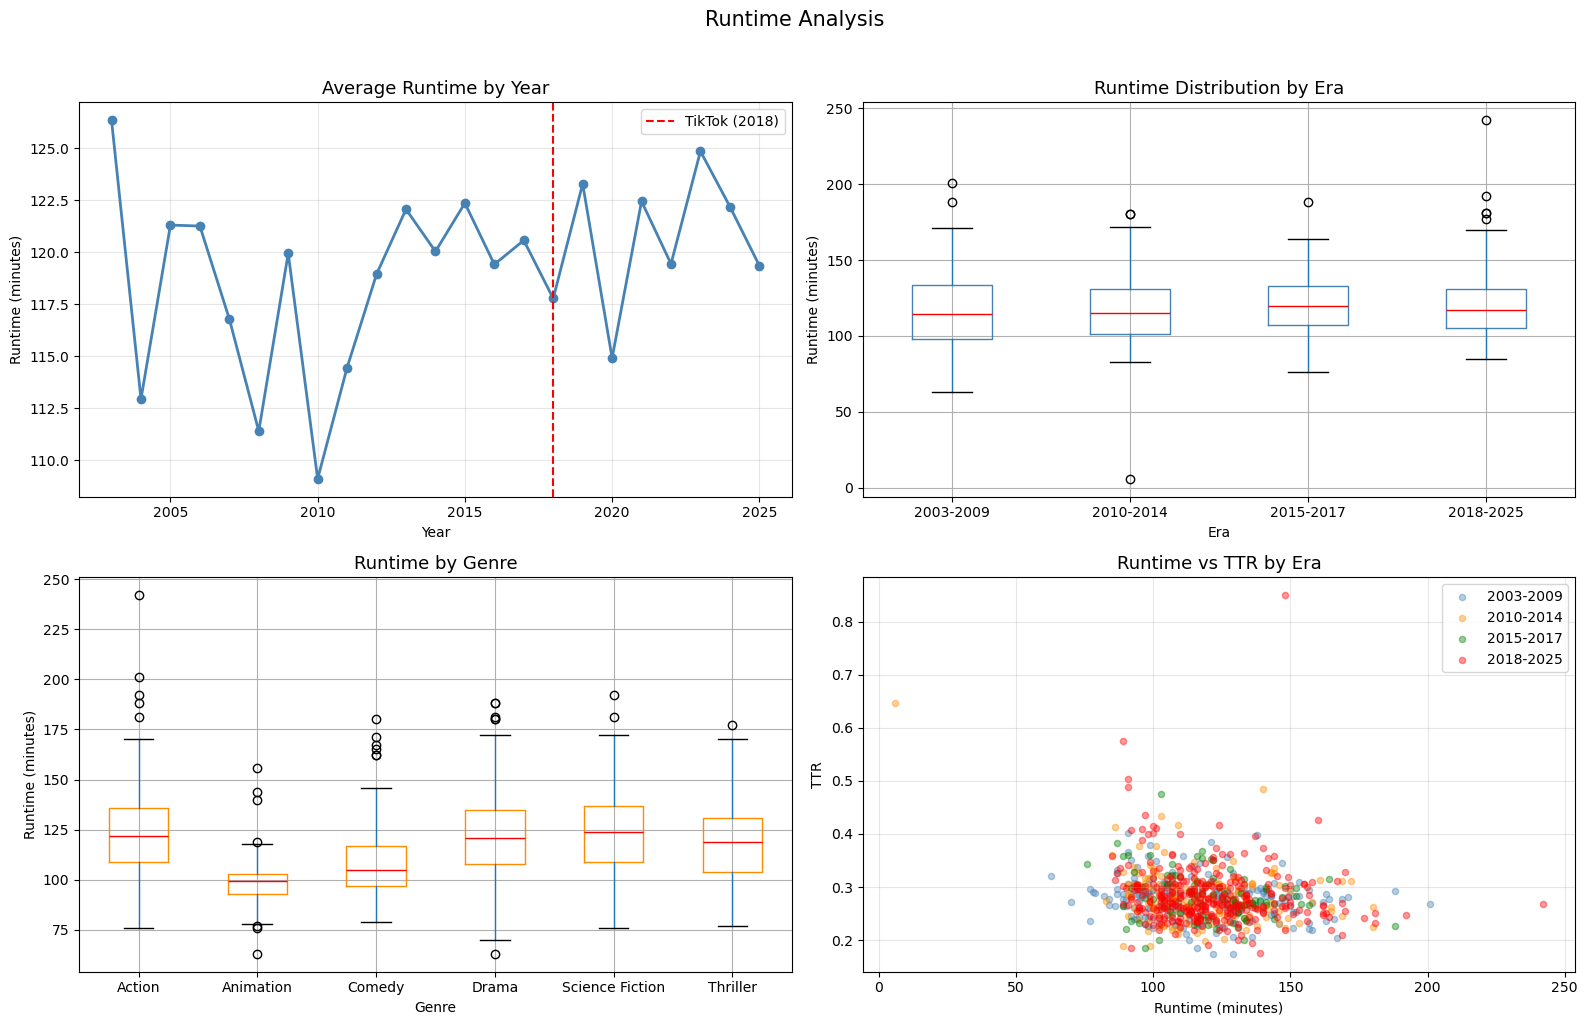


Average runtime by era:
era
2003-2009    117.7
2010-2014    117.2
2015-2017    120.8
2018-2025    120.5
Name: runtime, dtype: float64

Average runtime by genre:
genres_list
Action             123.7
Science Fiction    123.7
Drama              123.6
Thriller           119.7
Comedy             108.9
Animation           99.9
Name: runtime, dtype: float64


C:\Users\dhruv\AppData\Local\Temp\ipykernel_22112\2336771005.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_processed.groupby("era")["runtime"].mean().round(1))


In [32]:
# Runtime analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Average runtime over time
runtime_by_year = df_processed.groupby("year")["runtime"].mean()
axes[0,0].plot(runtime_by_year.index, runtime_by_year.values,
               marker="o", linewidth=2, color="steelblue")
axes[0,0].axvline(x=2018, color="red", linestyle="--", linewidth=1.5, label="TikTok (2018)")
axes[0,0].set_title("Average Runtime by Year", fontsize=13)
axes[0,0].set_xlabel("Year")
axes[0,0].set_ylabel("Runtime (minutes)")
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)

# Plot 2: Runtime distribution box plot by era
df_processed["era"] = pd.cut(df_processed["year"], 
                              bins=[2002, 2009, 2014, 2017, 2025],
                              labels=["2003-2009", "2010-2014", "2015-2017", "2018-2025"])
df_processed.boxplot(column="runtime", by="era", ax=axes[0,1], 
                     boxprops=dict(color="steelblue"),
                     medianprops=dict(color="red"))
axes[0,1].set_title("Runtime Distribution by Era", fontsize=13)
axes[0,1].set_xlabel("Era")
axes[0,1].set_ylabel("Runtime (minutes)")

# Plot 3: Runtime by genre (top 6)
runtime_genre = df_processed.copy()
runtime_genre["genres_list"] = runtime_genre["genres"].str.split("|")
runtime_genre = runtime_genre.explode("genres_list")
top_genres = ["Action", "Drama", "Comedy", "Thriller", "Animation", "Science Fiction"]
runtime_genre = runtime_genre[runtime_genre["genres_list"].isin(top_genres)]
runtime_genre.boxplot(column="runtime", by="genres_list", ax=axes[1,0],
                      boxprops=dict(color="darkorange"),
                      medianprops=dict(color="red"))
axes[1,0].set_title("Runtime by Genre", fontsize=13)
axes[1,0].set_xlabel("Genre")
axes[1,0].set_ylabel("Runtime (minutes)")

# Plot 4: Runtime vs TTR scatter coloured by era
colors = {"2003-2009": "steelblue", "2010-2014": "darkorange", 
          "2015-2017": "green", "2018-2025": "red"}
for era, group in df_processed.groupby("era"):
    axes[1,1].scatter(group["runtime"], group["ttr"], 
                      alpha=0.4, label=era, color=colors[era], s=20)
axes[1,1].set_title("Runtime vs TTR by Era", fontsize=13)
axes[1,1].set_xlabel("Runtime (minutes)")
axes[1,1].set_ylabel("TTR")
axes[1,1].legend()
axes[1,1].grid(alpha=0.3)

plt.suptitle("Runtime Analysis", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("./data/processed/runtime_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nAverage runtime by era:")
print(df_processed.groupby("era")["runtime"].mean().round(1))
print("\nAverage runtime by genre:")
print(runtime_genre.groupby("genres_list")["runtime"].mean().round(1).sort_values(ascending=False))